#**Importing the Libraries**

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#**Importing the Dataset**

In [38]:
dataset= pd.read_csv('diabetes_project_final.csv')
X=dataset.iloc[:, :-1].values
y=dataset.iloc[:, -1].values

#**Finding the missing data**

In [39]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer()
impute=SimpleImputer(missing_values=np.nan, strategy='median')
impute.fit(X)
impute.transform(X)
print(X)

[[1 1 1 ... 9 4 3]
 [0 0 0 ... 7 6 1]
 [1 1 1 ... 9 4 8]
 ...
 [0 0 1 ... 2 5 2]
 [1 0 1 ... 7 5 1]
 [1 1 1 ... 9 6 2]]


In [40]:
print(y)

[0 0 0 ... 0 0 1]


#**Taining and Test set SPLIT**

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.3, random_state=42)

In [42]:
print(X_train)

[[ 1  1  1 ... 12  3  1]
 [ 1  1  1 ... 11  5  3]
 [ 0  0  1 ...  5  6  8]
 ...
 [ 0  1  1 ...  9  6  8]
 [ 0  0  0 ...  5  6  6]
 [ 1  0  1 ... 11  5  6]]


In [43]:
print(X_test)

[[ 0  0  1 ...  7  4  2]
 [ 1  1  1 ... 13  6  6]
 [ 0  0  1 ...  1  4  7]
 ...
 [ 0  0  1 ...  5  6  7]
 [ 0  0  1 ... 12  6  7]
 [ 1  0  1 ... 13  5  4]]


In [44]:
print(y_train)

[1 0 0 ... 0 0 1]


In [45]:
print(y_test)

[0 0 0 ... 0 0 0]


#**Feature scailing**

In [46]:
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
X_train[:, [7,8,9,12,13,14]]=sc.fit_transform(X_train[:, [7,8,9,12,13,14]])
print(X_train[:, [7,8,9,12,13,14]])

[[ 0  0  0  0  2  0]
 [ 0  0  0  0  0  0]
 [ 0  0  0  0  0  0]
 ...
 [ 0  0  0  0  0  0]
 [-1  0  0  3  0  0]
 [-1  0  0  0  0  1]]


In [47]:
X_test[:, [7,8,9,12,13,14]] = sc.transform(X_test[:, [7,8,9,12,13,14]])
print(X_test)

[[ 0  0  1 ...  7  4  2]
 [ 1  1  1 ... 13  6  6]
 [ 0  0  1 ...  1  4  7]
 ...
 [ 0  0  1 ...  5  6  7]
 [ 0  0  1 ... 12  6  7]
 [ 1  0  1 ... 13  5  4]]


In [48]:
print(X_train.shape)
print(y_train.shape)

(177576, 21)
(177576,)


#SMOTE (synthetic Minority Oversampling Technique)

In [49]:
from imblearn.over_sampling import SMOTE

In [50]:
!pip install imbalanced-learn

In [51]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=0)

X_train, y_train = sm.fit_resample(X_train, y_train)

In [53]:
from collections import Counter
print(Counter(y_train))

Counter({np.int64(1): 152729, np.int64(0): 152729})


#Logistic Regression

In [54]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression(random_state=0, max_iter=5000)
classifier.fit(X_train, y_train)

LogisticRegression(max_iter=5000, random_state=0)

In [55]:
y_pred=classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[0 0]
 [1 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [1 0]]


In [56]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm=confusion_matrix(y_test, y_pred)
print(cm)
y_pred_lr=accuracy_score(y_test, y_pred)
print(y_pred_lr)

[[47172 18433]
 [ 3187  7312]]
0.7159150635971828


# SVM kernel

In [ ]:
from sklearn.svm import SVC
classifier=SVC(kernel='linear', random_state=0)
classifier.fit(X_train, y_train)

In [ ]:
y_pred=classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm=confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

# Random Forest

In [57]:
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0)
classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', random_state=0)

In [58]:
y_pred=classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [1 0]
 [1 0]]


In [59]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm=confusion_matrix(y_test, y_pred)
print(cm)
y_pred_rf=accuracy_score(y_test, y_pred)
print(y_pred_rf)

[[54059 11546]
 [ 5446  5053]]
0.7767265846736046


In [60]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.82      0.86     65605
           1       0.30      0.48      0.37     10499

    accuracy                           0.78     76104
   macro avg       0.61      0.65      0.62     76104
weighted avg       0.83      0.78      0.80     76104



# Naive Bayes

In [61]:
from sklearn.naive_bayes import GaussianNB
classifier=GaussianNB()
classifier.fit(X_train, y_train)

GaussianNB()

In [62]:
y_pred=classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[1 0]
 [1 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [1 0]]


In [63]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm=confusion_matrix(y_test, y_pred)
print(cm)
y_pred_nb=accuracy_score(y_test, y_pred)
print(y_pred_nb)

[[38464 27141]
 [ 1685  8814]]
0.6212288447387785


In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.59      0.73     65605
           1       0.25      0.84      0.38     10499

    accuracy                           0.62     76104
   macro avg       0.60      0.71      0.55     76104
weighted avg       0.86      0.62      0.68     76104



#Decision Tree

In [72]:
from sklearn.tree import DecisionTreeClassifier
classifier= DecisionTreeClassifier(criterion = 'entropy', random_state=42)
classifier.fit(X_train , y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [73]:
y_pred=classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [1 0]
 [1 0]]


In [76]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm=confusion_matrix(y_pred, y_test)
print(cm)
y_pred_dt=accuracy_score(y_pred, y_test)
print(y_pred_dt)

[[51726  5970]
 [13879  4529]]
0.7391858509408178


In [86]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.79      0.84     65605
           1       0.25      0.43      0.31     10499

    accuracy                           0.74     76104
   macro avg       0.57      0.61      0.58     76104
weighted avg       0.81      0.74      0.77     76104



#ROC Curve

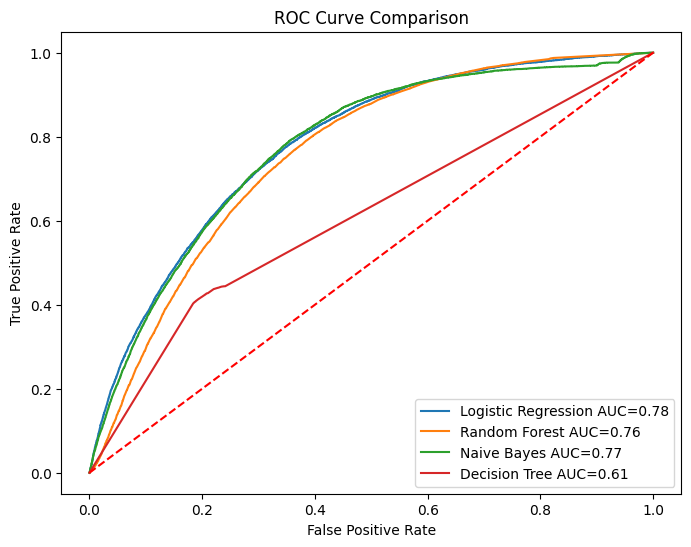

In [77]:
from sklearn.metrics import roc_curve, auc
lr = LogisticRegression(random_state=0, max_iter=5000)
lr.fit(X_train, y_train)

y_prob_lr = lr.predict_proba(X_test)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)


# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    random_state=0
)

rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)


# Naive Bayes
nb = GaussianNB()

nb.fit(X_train, y_train)

y_prob_nb = nb.predict_proba(X_test)[:,1]

fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_nb = auc(fpr_nb, tpr_nb)

#decision tree
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_prob_dt = dt.predict_proba(X_test)[:,1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)


# Plot ROC Curves
plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression AUC={auc_lr:.2f}'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest AUC={auc_rf:.2f}'
)

plt.plot(
    fpr_nb,
    tpr_nb,
    label=f'Naive Bayes AUC={auc_nb:.2f}'
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f'Decision Tree AUC={auc_dt:.2f}'
)

# Random prediction line
plt.plot([0,1],[0,1],'r--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve Comparison')

plt.legend()

plt.show()

In [79]:
from sklearn.metrics import roc_auc_score
accuracy_results = []
auc_results = []
accuracy_results.append(
    ['Logistic Regression',
     accuracy_score(y_test, y_pred)]
)

auc_results.append(
    ['Logistic Regression',
     roc_auc_score(y_test, y_prob_lr)]
)
accuracy_results.append(
    ['Random Forest',
     accuracy_score(y_test, y_pred)]
)

auc_results.append(
    ['Random Forest',
     roc_auc_score(y_test, y_prob_rf)]
)
accuracy_results.append(
    ['Naive Bayes',
     accuracy_score(y_test, y_pred)]
)

auc_results.append(
    ['Naive Bayes',
     roc_auc_score(y_test, y_prob_nb)]

)
auc_results.append(
    ['Decision tree',
     roc_auc_score(y_test, y_prob_dt)]
)
accuracy_results.append(
    ['Decision tree',
     accuracy_score(y_test, y_pred)]
)
# ROC-AUC Table
auc_df = pd.DataFrame(
    auc_results,
    columns=['Model','ROC-AUC']
)

auc_df = auc_df.sort_values(
    by='ROC-AUC',
    ascending=False
)

print(auc_df)

                 Model   ROC-AUC
0  Logistic Regression  0.780159
2          Naive Bayes  0.774948
1        Random Forest  0.758663
3        Decision tree  0.609595


In [84]:
accuracy_results=[]

accuracy_results.append(
['Logistic Regression',
 y_pred_lr]      # already stores accuracy value
)

accuracy_results.append(
['Random Forest',
 y_pred_rf]
)

accuracy_results.append(
['Naive Bayes',
 y_pred_nb]
)
accuracy_results.append(
['Decision tree',
 y_pred_dt]
)

In [85]:
# Accuracy Table

accuracy_df = pd.DataFrame(

    accuracy_results,
    columns=['Model','Accuracy']

)

accuracy_df = accuracy_df.sort_values(

    by='Accuracy',
    ascending=False

)

print(accuracy_df)

                 Model  Accuracy
1        Random Forest  0.776727
3        Decision tree  0.739186
0  Logistic Regression  0.715915
2          Naive Bayes  0.621229
